# Preprocessing, Training, Evaluation & Export
**Task:** Periapical Lesion Detection — Model Training & Inference  
**Model:** YOLO11l (YOLO11 Large)  
**Prerequisites:** Run `01_data_preparation.ipynb` first to generate the YOLO dataset on Drive.

---
### Notebook Outline
1. Environment Setup
2. Google Drive Mounting & Path Configuration
3. Preprocessing Pipeline (CLAHE + Normalisation + Tiling)
4. Model Initialization & Training
5. Evaluation on Test Set
6. Visualization of Predictions
7. Error Analysis
8. Model Export
9. Inference Utility Function

## 1. Environment Setup

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
# ultralytics >= 8.3 ships YOLO11; opencv-python-headless for CLAHE
!pip install ultralytics --quiet
!pip install opencv-python-headless Pillow matplotlib PyYAML --quiet

import os, shutil, random, time, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import cv2
import yaml
import torch
from tqdm.auto import tqdm

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── GPU check ───────────────────────────────────────────────────────────────
print('=' * 55)
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  No GPU found – switch runtime to GPU (Runtime → Change runtime type → T4)')
print('=' * 55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.4 MB/s eta 0:00:00
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA A100-SXM4-40GB
VRAM            : 42.4 GB


## 2. Google Drive Mounting & Path Configuration

> These paths must match what was set in **Notebook 1**.

In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ──  Must match Notebook 1 paths ─────────────────────────────────────────
WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks')
DATASET_DIR = WORK_DIR / ''          # original YOLO dataset from Notebook 1
TILED_DIR   = WORK_DIR / 'filtered_tiles'    # preprocessed + tiled dataset (created here)
yaml_path   = TILED_DIR / 'data.yaml'       # points to tiled split after Section 3
# ────────────────────────────────────────────────────────────────────────────

CLASS_DISPLAY = ['Periapical_Type3', 'Periapical_Type4', 'Periapical_Type5']
NC = len(CLASS_DISPLAY)

# ── Verify original dataset exists ──────────────────────────────────────────
checks = {
    'data.yaml'   : DATASET_DIR / 'data.yaml',
    'train images': DATASET_DIR / 'images' / 'train',
    'valid images': DATASET_DIR / 'images' / 'valid',
    'test images' : DATASET_DIR / 'images' / 'test',
    'train labels': DATASET_DIR / 'labels' / 'train',
}
print('Checking dataset paths from Notebook 1:')
all_ok = True
for name, p in checks.items():
    ok = p.exists()
    all_ok = all_ok and ok
    status = ' ok' if ok else ' MISSING'
    print(f'  {status}  {name:<15} : {p}')

if not all_ok:
    print('\n  Some paths are missing. Please run Notebook 1 first!')
else:
    print('\n  Dataset ready – proceeding to preprocessing.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking dataset paths from Notebook 1:
   MISSING  data.yaml       : /content/drive/MyDrive/Colab Notebooks/data.yaml
   MISSING  train images    : /content/drive/MyDrive/Colab Notebooks/images/train
   MISSING  valid images    : /content/drive/MyDrive/Colab Notebooks/images/valid
   MISSING  test images     : /content/drive/MyDrive/Colab Notebooks/images/test
   MISSING  train labels    : /content/drive/MyDrive/Colab Notebooks/labels/train

  Some paths are missing. Please run Notebook 1 first!


## 3. Preprocessing Pipeline

Panoramic dental X-rays require special treatment before training:

| Step | Why it matters |
|---|---|
| **CLAHE** | Periapical lesions have low local contrast; CLAHE boosts subtle bone-density differences without blowing out highlights |
| **Normalisation** | Stabilises gradient flow; required when mixing scanners with different exposure levels |
| **Grayscale → RGB** | YOLO11 pretrained on ImageNet (3-ch); duplicating the channel lets the backbone reuse all pretrained weights |
| **Tiling** | Panoramics are wide (~2000–4000 px); small lesions (<32 px) vanish at 640-input resolution. 1280×1280 tiles keep sub-pixel detail |

In [ ]:
# ── CLAHE + normalisation helpers ────────────────────────────────────────────

def apply_clahe(img_bgr: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid: tuple = (8, 8)) -> np.ndarray:
    """
    Apply Contrast Limited Adaptive Histogram Equalisation (CLAHE).

    Why CLAHE over global equalisation?
    - Dental X-rays have large uniform regions (air, enamel) that dominate
      a global histogram, compressing the periapical area contrast.
    - CLAHE works on local tiles so it amplifies the low-contrast
      bone-resorption zone around the lesion without over-amplifying noise.
    - clipLimit=2.0 prevents salt-and-pepper artefacts on high-noise scans.
    """
    # Convert to LAB so CLAHE is applied only to luminance (L channel)
    # This avoids colour artefacts (relevant when images are already pseudo-colour)
    if img_bgr.ndim == 2:
        # Pure grayscale: apply CLAHE directly
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
        enhanced = clahe.apply(img_bgr)
    else:
        lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
        l_eq  = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)
    return enhanced


def preprocess_image(img_path: Path) -> np.ndarray:
    """
    Full preprocessing pipeline for a single dental X-ray:
      1. Load (handles 8-bit and 16-bit DICOM-derived images)
      2. Apply CLAHE for local contrast enhancement
      3. Normalise to [0, 1] then back to uint8 [0, 255]
      4. Convert to 3-channel RGB for YOLO11 backbone compatibility

    Returns
    -------
    np.ndarray  HxWx3 uint8 RGB image
    """
    # -- Load with OpenCV (supports 16-bit) --------------------------------
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f'Cannot open: {img_path}')

    # -- Normalise bit-depth to 8-bit --------------------------------------
    # 16-bit DICOM scans need rescaling before CLAHE (which expects uint8)
    if img.dtype == np.uint16:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # -- CLAHE contrast enhancement ----------------------------------------
    img = apply_clahe(img, clip_limit=2.0, tile_grid=(8, 8))

    # -- Pixel normalisation to [0,1] then back to uint8 -------------------
    # Normalising ensures consistency across scanners with different
    # exposure levels; we convert back to uint8 so cv2/PIL can save as PNG.
    img_f  = img.astype(np.float32) / 255.0
    img    = (img_f * 255).astype(np.uint8)

    # -- Convert to 3-channel RGB ------------------------------------------
    # YOLO11 pretrained backbone expects 3 channels; duplicating the
    # luminance channel preserves all spatial information.
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img  # HxWx3 uint8


print(' Preprocessing helpers defined.')

 Preprocessing helpers defined.


In [ ]:
# ── Tiling helpers ───────────────────────────────────────────────────────────

TILE_SIZE    = 1280   # px  – large enough to see fine bone detail
OVERLAP_FRAC = 0.175  # 17.5% overlap (midpoint of recommended 15–20%)
MIN_BOX_PX   = 4      # discard remapped boxes smaller than this in either dim
MIN_VIS_FRAC = 0.20   # a GT box must have ≥20% of its area inside the tile to be kept


def yolo_to_abs(label_line: str, img_w: int, img_h: int):
    """
    Convert a single YOLO label line (normalised xywh) to
    absolute pixel coordinates (cls, x1, y1, x2, y2).
    """
    parts   = label_line.strip().split()
    if len(parts) != 5:
        return None
    cls_id          = int(parts[0])
    xc, yc, bw, bh = map(float, parts[1:])
    x1 = (xc - bw / 2) * img_w
    y1 = (yc - bh / 2) * img_h
    x2 = (xc + bw / 2) * img_w
    y2 = (yc + bh / 2) * img_h
    return cls_id, x1, y1, x2, y2


def remap_box_to_tile(cls_id, x1, y1, x2, y2,
                      tx, ty, tile_w, tile_h):
    """
    Remap an absolute bounding box to a tile's local coordinate space
    and return a YOLO-format normalised label string, or None if the box
    falls outside the minimum visibility threshold.

    Strategy: clip the box to the tile boundary; compute the fraction of
    the original box area that remains.  If < MIN_VIS_FRAC we skip the
    box to avoid training on nearly-invisible annotations.
    """
    # Clip to tile
    cx1 = max(x1, tx)
    cy1 = max(y1, ty)
    cx2 = min(x2, tx + tile_w)
    cy2 = min(y2, ty + tile_h)

    if cx2 <= cx1 or cy2 <= cy1:
        return None  # box fully outside tile

    # Visibility check
    orig_area    = max(1e-6, (x2 - x1) * (y2 - y1))
    clipped_area = (cx2 - cx1) * (cy2 - cy1)
    if clipped_area / orig_area < MIN_VIS_FRAC:
        return None

    # Minimum absolute size check
    if (cx2 - cx1) < MIN_BOX_PX or (cy2 - cy1) < MIN_BOX_PX:
        return None

    # Convert to tile-local normalised YOLO format
    lx1 = cx1 - tx;  ly1 = cy1 - ty
    lx2 = cx2 - tx;  ly2 = cy2 - ty
    xc_n = (lx1 + lx2) / 2 / tile_w
    yc_n = (ly1 + ly2) / 2 / tile_h
    bw_n = (lx2 - lx1) / tile_w
    bh_n = (ly2 - ly1) / tile_h

    # Clamp to [0,1]
    xc_n = min(max(xc_n, 0), 1)
    yc_n = min(max(yc_n, 0), 1)
    bw_n = min(max(bw_n, 0), 1)
    bh_n = min(max(bh_n, 0), 1)

    return f'{cls_id} {xc_n:.6f} {yc_n:.6f} {bw_n:.6f} {bh_n:.6f}'


def tile_image_and_labels(img_rgb: np.ndarray,
                           raw_labels: list,
                           tile_size: int  = TILE_SIZE,
                           overlap:   float = OVERLAP_FRAC):
    """
    Slice a preprocessed image into overlapping square tiles and
    remap all YOLO bounding boxes into each tile's local space.

    Returns
    -------
    list of (tile_np_array, [label_str, ...]) tuples
    """
    H, W  = img_rgb.shape[:2]
    stride = int(tile_size * (1 - overlap))

    # Parse all GT boxes once
    gt_boxes = []
    for line in raw_labels:
        parsed = yolo_to_abs(line, W, H)
        if parsed:
            gt_boxes.append(parsed)  # (cls_id, x1, y1, x2, y2)

    tiles = []
    for ty in range(0, H, stride):
        for tx in range(0, W, stride):
            # Actual tile dimensions (edge tiles may be smaller)
            tw = min(tile_size, W - tx)
            th = min(tile_size, H - ty)

            # Pad edge tiles to full tile_size so YOLO sees a uniform shape
            tile = np.zeros((tile_size, tile_size, 3), dtype=np.uint8)
            tile[:th, :tw] = img_rgb[ty:ty+th, tx:tx+tw]

            tile_labels = []
            for (cls_id, x1, y1, x2, y2) in gt_boxes:
                lbl = remap_box_to_tile(cls_id, x1, y1, x2, y2,
                                        tx, ty, tile_size, tile_size)
                if lbl:
                    tile_labels.append(lbl)

            tiles.append((tile, tile_labels))

    return tiles


print(' Tiling helpers defined.')

 Tiling helpers defined.


In [ ]:
# ── Build the tiled dataset ──────────────────────────────────────────────────

SPLITS = ['train', 'valid', 'test']

def process_split(split: str,
                  src_dir: Path,
                  dst_dir: Path,
                  tile: bool = True):
    """
    Preprocesses and (optionally) tiles one dataset split.
    Test split is NOT tiled – we want whole-image evaluation.

    Notes
    -----
    - Tiling is applied to train/valid only so mAP numbers remain
      comparable to the original full-image test set.
    - Each tile is saved as a lossless PNG to preserve bit accuracy.
    """
    img_src = src_dir / 'images' / split
    lbl_src = src_dir / 'labels' / split
    img_dst = dst_dir / 'images' / split
    lbl_dst = dst_dir / 'labels' / split
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    img_files = sorted(img_src.glob('*.jpg')) + sorted(img_src.glob('*.png'))
    n_tiles_total = 0

    for img_path in tqdm(img_files, desc=f'{split:>6}'):
        # 1. Preprocess (CLAHE + normalise + ensure 3-ch)
        try:
            img_rgb = preprocess_image(img_path)
        except Exception as e:
            print(f'  WARN: skipping {img_path.name}: {e}')
            continue

        # 2. Load ground-truth labels
        lbl_file = lbl_src / (img_path.stem + '.txt')
        raw_labels = []
        if lbl_file.exists():
            raw_labels = lbl_file.read_text().strip().splitlines()
            raw_labels = [l for l in raw_labels if l.strip()]

        if not tile:
            # Test set: just save preprocessed full image
            out_png = img_dst / (img_path.stem + '.png')
            cv2.imwrite(str(out_png), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
            out_lbl = lbl_dst / (img_path.stem + '.txt')
            out_lbl.write_text('\n'.join(raw_labels))
            n_tiles_total += 1
        else:
            # Train/valid: tile and remap
            tiles = tile_image_and_labels(img_rgb, raw_labels)
            for ti, (tile_arr, tile_labels) in enumerate(tiles):
                stem = f'{img_path.stem}_t{ti:04d}'
                # Save tile image
                cv2.imwrite(
                    str(img_dst / (stem + '.png')),
                    cv2.cvtColor(tile_arr, cv2.COLOR_RGB2BGR)
                )
                # Save tile labels (empty file = background tile, still valid)
                (lbl_dst / (stem + '.txt')).write_text('\n'.join(tile_labels))
                n_tiles_total += 1

    print(f'  {split}: {len(img_files)} images → {n_tiles_total} tiles/files saved')
    return n_tiles_total


print('Starting preprocessing pipeline…')
print(f'  Tile size      : {TILE_SIZE}×{TILE_SIZE}')
print(f'  Overlap        : {OVERLAP_FRAC*100:.0f}%')
print(f'  Min box px     : {MIN_BOX_PX}')
print(f'  Min visibility : {MIN_VIS_FRAC*100:.0f}%')
print()

for split in SPLITS:
    process_split(
        split,
        src_dir = DATASET_DIR,
        dst_dir = TILED_DIR,
        tile    = (split != 'test')   # do NOT tile the test set
    )

print('\n Preprocessing + tiling complete.')

Starting preprocessing pipeline…
  Tile size      : 1280×1280
  Overlap        : 18%
  Min box px     : 4
  Min visibility : 20%



 train:   0%|          | 0/2746 [00:00<?, ?it/s]

In [6]:
# # ── Write data.yaml for the tiled dataset ────────────────────────────────────
# data_yaml = {
#     'path'  : str(TILED_DIR),
#     'train' : 'images/train',
#     'val'   : 'images/valid',
#     'test'  : 'images/test',
#     'nc'    : NC,
#     'names' : CLASS_DISPLAY,
# }
# with open(yaml_path, 'w') as f:
#     yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

# print(f' data.yaml written to: {yaml_path}')

# # Quick sanity check: count tiles
# for split in SPLITS:
#     n = len(list((TILED_DIR / 'images' / split).glob('*.png')))
#     print(f'  {split:>6}: {n} tiles/images')

In [15]:
# ── Quick visual sanity check: show tiles side-by-side ─────────────

sample_tiles = sorted((TILED_DIR / 'images' / 'train').glob('*.png'))[:10]

ncols = 2
nrows = (len(sample_tiles) + 1) // 2

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))

if nrows == 1:
    axes = np.array([axes])

axes = axes.flatten()

for ax, tp in zip(axes, sample_tiles):

    img = np.array(Image.open(tp))

    ax.imshow(img, cmap='gray')
    ax.set_title(tp.name, fontsize=8)
    ax.axis('off')

for ax in axes[len(sample_tiles):]:
    ax.axis('off')

fig.suptitle(
    'Preprocessed + Tiled Training Samples',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# from pathlib import Path
# import shutil

# # =========================
# # CONFIG
# # =========================

# SRC_DIR = Path("/content/drive/MyDrive/Colab Notebooks/dataset_tiled")
# DST_DIR = Path("/content/drive/MyDrive/Colab Notebooks/filtered_tiles")

# SPLITS = ["train", "valid"]

# KEEP_SUFFIXES = {
#     "_t0000",
#     "_t0001",
# }

# # =========================
# # MAIN
# # =========================

# copied = 0
# skipped = 0

# for split in SPLITS:

#     src_img_dir = SRC_DIR / "images" / split
#     src_lbl_dir = SRC_DIR / "labels" / split

#     dst_img_dir = DST_DIR / "images" / split
#     dst_lbl_dir = DST_DIR / "labels" / split

#     dst_img_dir.mkdir(parents=True, exist_ok=True)
#     dst_lbl_dir.mkdir(parents=True, exist_ok=True)

#     img_files = (
#         list(src_img_dir.glob("*.png")) +
#         list(src_img_dir.glob("*.jpg")) +
#         list(src_img_dir.glob("*.jpeg"))
#     )

#     for img_path in img_files:

#         stem = img_path.stem

#         if not any(stem.endswith(s) for s in KEEP_SUFFIXES):
#             skipped += 1
#             continue

#         lbl_path = src_lbl_dir / f"{stem}.txt"

#         shutil.copy2(
#             img_path,
#             dst_img_dir / img_path.name
#         )

#         if lbl_path.exists():
#             shutil.copy2(
#                 lbl_path,
#                 dst_lbl_dir / lbl_path.name
#             )

#         copied += 1

# print(f" Copied: {copied}")
# print(f" Skipped: {skipped}")

## 4. Model Initialization & Training

### Why YOLO11l?
- **YOLO11** architecture improves small-object recall over v10 via enhanced neck feature fusion.
- **Large (l) variant**: deeper network ↔ better gradient signal for subtle density changes.
- **imgsz=1280**: matches tile size, avoids down/up-scaling artefacts during inference.
- **rect=True**: efficient variable-ratio batching within the square tiles.
- **close_mosaic=10**: disables mosaic for the last 10 epochs so the model can fine-tune on clean images, reducing the train→val domain gap.

In [16]:
from ultralytics import YOLO

MODEL_NAME = 'yolo11l.pt'   # downloaded automatically if not cached
RUN_NAME   = 'periapical_det_v55'
PROJECT    = str(WORK_DIR / 'runs')

model = YOLO(MODEL_NAME)
print(f' Model loaded : {MODEL_NAME}')
print(f'   Parameters   : {sum(p.numel() for p in model.model.parameters()) / 1e6:.1f} M')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Model loaded : yolo11l.pt
   Parameters   : 25.4 M


In [17]:
# ── Training ─────────────────────────────────────────────────────────────────
t_start = time.time()

results = model.train(
    data         = str(yaml_path),
    epochs       = 50,
    imgsz        = 1280,           # matches tile size for zero-scale mismatch
    batch        = 4,              # T4 16 GB @ 1280 with YOLO11l; raise to 8 if headroom
    optimizer    = 'AdamW',
    lr0          = 0.001,
    cos_lr       = True,           # cosine annealing → smoother convergence
    weight_decay = 0.0005,
    patience     = 20,             # early stopping on plateau
    cache        = True,           # cache tiles in RAM for faster epoch iteration
    rect         = True,           # rectangular batching; reduces black-bar padding
    close_mosaic = 10,             # disable mosaic last 10 eps → clean-image fine-tune
    # ── Medical-imaging-safe augmentations ──────────────────────────────────
    # Dental X-rays are grayscale + standardised acquisition;
    # aggressive colour/warp augmentations hurt more than help.
    degrees      = 3,              # small rotation (patient positioning variability)
    translate    = 0.03,           # minimal shift
    scale        = 0.10,           # gentle scale jitter
    fliplr       = 0.5,            # horizontal flip (symmetric anatomy)
    flipud       = 0.0,            # NO vertical flip (orientation matters clinically)
    mosaic       = 0.05,           # very low mosaic – avoids unrealistic composites
    mixup        = 0.0,            # off – mixup blurs lesion edges
    perspective  = 0.0,            # off – X-ray projection already corrected
    shear        = 0.0,            # off – shear distorts bone geometry
    copy_paste   = 0.0,            # off – not valid for density-based imaging
    hsv_h        = 0.0,            # no hue shift (grayscale images)
    hsv_s        = 0.0,            # no saturation shift (grayscale images)
    hsv_v        = 0.1,            # tiny brightness jitter for exposure variability
    # ── Misc ────────────────────────────────────────────────────────────────
    plots        = True,
    save         = True,
    project      = PROJECT,
    name         = RUN_NAME,
    exist_ok     = True,
    seed         = SEED,
    workers      = 4,
    device       = 0,
    verbose      = True,
)

t_end   = time.time()
elapsed = t_end - t_start
h, rem  = divmod(int(elapsed), 3600)
m, s    = divmod(rem, 60)
print(f'\n  Total training time: {h:02d}h {m:02d}m {s:02d}s')

# ── Key metrics ──────────────────────────────────────────────────────────────
try:
    metrics = results.results_dict
    print('\n Final Training Metrics:')
    print(f"   mAP50      (box) : {metrics.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"   mAP50-95   (box) : {metrics.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print(f"   Precision        : {metrics.get('metrics/precision(B)', 'N/A'):.4f}")
    print(f"   Recall           : {metrics.get('metrics/recall(B)', 'N/A'):.4f}")
    print(f"   Box loss         : {metrics.get('train/box_loss', 'N/A'):.4f}")
    print(f"   Cls loss         : {metrics.get('train/cls_loss', 'N/A'):.4f}")
    print(f"   DFL loss         : {metrics.get('train/dfl_loss', 'N/A'):.4f}")
except Exception as e:
    print(f'   (Could not parse metrics dict: {e})')

BEST_PT = Path(PROJECT) / RUN_NAME / 'weights' / 'best.pt'
print(f'\n Best model saved at: {BEST_PT}')

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/filtered_tiles/data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=0.05, multi_scale=0.0, name=periapical_det_v55, nbs=64, nms=False, opset=None, optimize=Fal

## 5. Evaluation on Test Set

In [18]:
# ── Load best weights ────────────────────────────────────────────────────────
best_model = YOLO(str(BEST_PT))

test_metrics = best_model.val(
    data     = str(yaml_path),
    split    = 'test',
    imgsz    = 1280,
    batch    = 8,
    device   = 0,
    plots    = True,
    save_json= True,
    project  = PROJECT,
    name     = RUN_NAME + '_test_eval',
    exist_ok = True,
    verbose  = True,
)

print('\n Test Set Evaluation:')
print(f'   mAP50 (box)    : {test_metrics.box.map50:.4f}')
print(f'   mAP50-95 (box) : {test_metrics.box.map:.4f}')
print(f'   Precision      : {test_metrics.box.mp:.4f}')
print(f'   Recall         : {test_metrics.box.mr:.4f}')

print('\n   Per-class AP50 (detection):')
try:
    per_class_ap50 = test_metrics.box.ap50
    for i, name in enumerate(CLASS_DISPLAY):
        print(f'     [{i}] {name:<25} AP50={per_class_ap50[i]:.4f}')
except Exception as e:
    print(f'   (Per-class metrics unavailable: {e})')

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,281,625 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 3.7±0.2 MB/s, size: 4036.3 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/filtered_tiles/labels/test... 590 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 590/590 3.9it/s 2:32
val: New cache created: /content/drive/MyDrive/Colab Notebooks/filtered_tiles/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 7.6it/s 9.7s
                   all        590       1013     0.0921       0.14     0.0441      0.015
      Periapical_Type3        426        643     0.0984      0.173      0.038     0.0102
      Periapical_Type4        213        258     0.0862      0.132     0.0495      0.018
      Periapical_Type5        107        112     0.0916      0.116     0.0448     0.0168

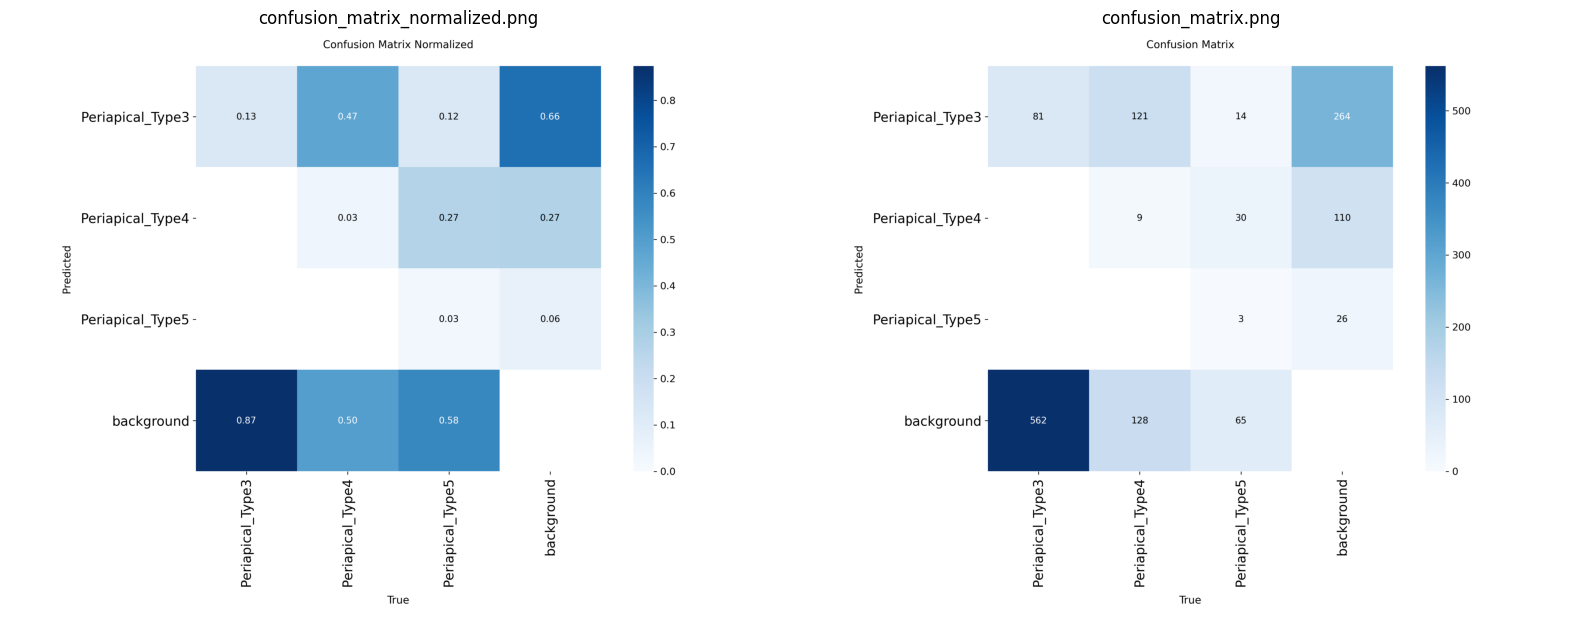

In [19]:
# ── Display confusion matrix saved by val() ──────────────────────────────────
EVAL_DIR = Path(PROJECT) / (RUN_NAME + '_test_eval')
cm_imgs  = list(EVAL_DIR.glob('confusion_matrix*.png'))
if cm_imgs:
    fig, axes = plt.subplots(1, len(cm_imgs), figsize=(8 * len(cm_imgs), 7))
    if len(cm_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, cm_imgs):
        ax.imshow(plt.imread(p))
        ax.axis('off')
        ax.set_title(p.name)
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix image not found – check', EVAL_DIR)

## 6. Visualization of Predictions on Test Images

Test images found: 590


/tmp/ipykernel_2912/2779636104.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


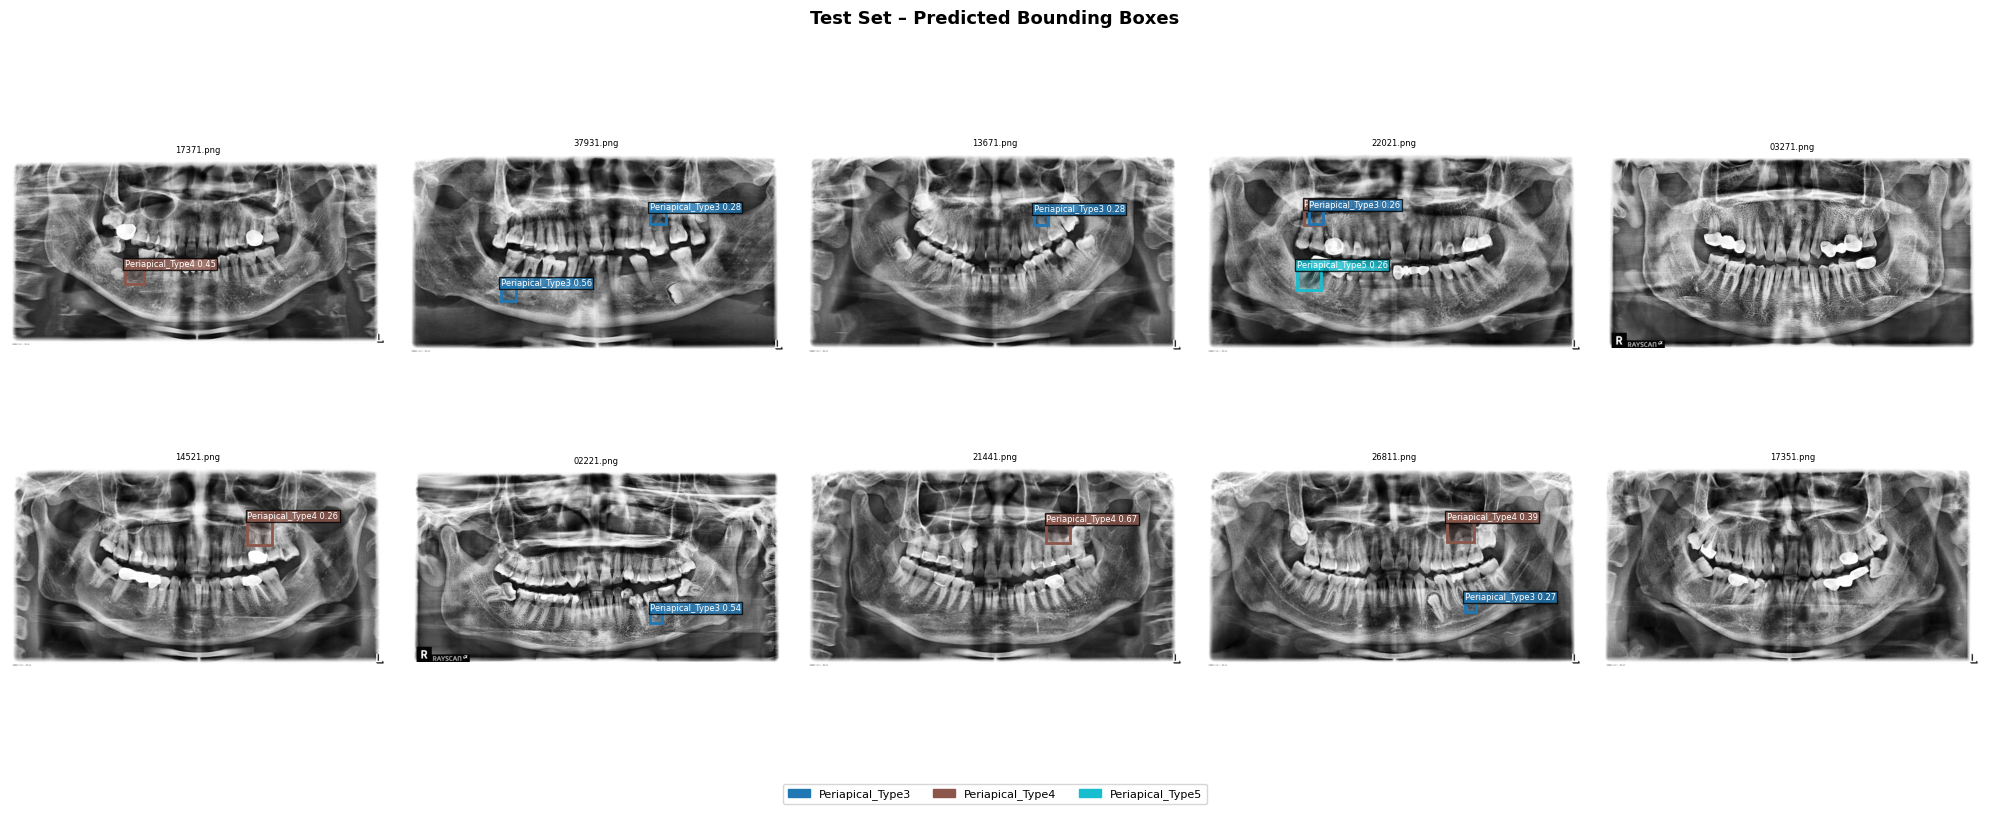

In [20]:
def plot_predictions(model, img_paths: list, class_names: list,
                     conf: float = 0.25, n: int = 10,
                     title: str = 'Predictions'):
    """Run inference and visualise predicted bounding boxes."""
    samples = random.sample(img_paths, min(n, len(img_paths)))
    cols    = 5
    rows    = math.ceil(len(samples) / cols)
    cmap    = plt.cm.get_cmap('tab10', len(class_names))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes[:len(samples)], samples):
        preds = model.predict(source=str(img_path), conf=conf,
                              verbose=False, imgsz=1280)
        r   = preds[0]
        img = np.array(Image.open(img_path).convert('RGB'))

        ax.imshow(img)
        ax.set_title(Path(img_path).name, fontsize=6)
        ax.axis('off')

        if r.boxes is not None and len(r.boxes):
            for box, cls_id, score in zip(
                    r.boxes.xyxy.cpu().numpy(),
                    r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy()):
                color = cmap(cls_id)
                x1, y1, x2, y2 = box
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor=color,
                                           facecolor=(*color[:3], 0.15))
                ax.add_patch(rect)
                ax.text(x1, y1 - 4,
                        f'{class_names[cls_id]} {score:.2f}',
                        color='white', fontsize=6,
                        bbox=dict(facecolor=color, alpha=0.8, pad=1))

    for ax in axes[len(samples):]:
        ax.axis('off')

    legend = [mpatches.Patch(color=cmap(i), label=class_names[i])
              for i in range(len(class_names))]
    fig.legend(handles=legend, loc='lower center', ncol=len(class_names),
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Reload test images list ──────────────────────────────────────────────────
# Use PREPROCESSED test images (TILED_DIR) so inference matches training domain
test_imgs = (
    sorted((TILED_DIR / 'images' / 'test').glob('*.jpg')) +
    sorted((TILED_DIR / 'images' / 'test').glob('*.png'))
)
print(f'Test images found: {len(test_imgs)}')

plot_predictions(best_model, test_imgs, CLASS_DISPLAY,
                 conf=0.25, n=10, title='Test Set – Predicted Bounding Boxes')

/tmp/ipykernel_2912/122792281.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', len(class_names))


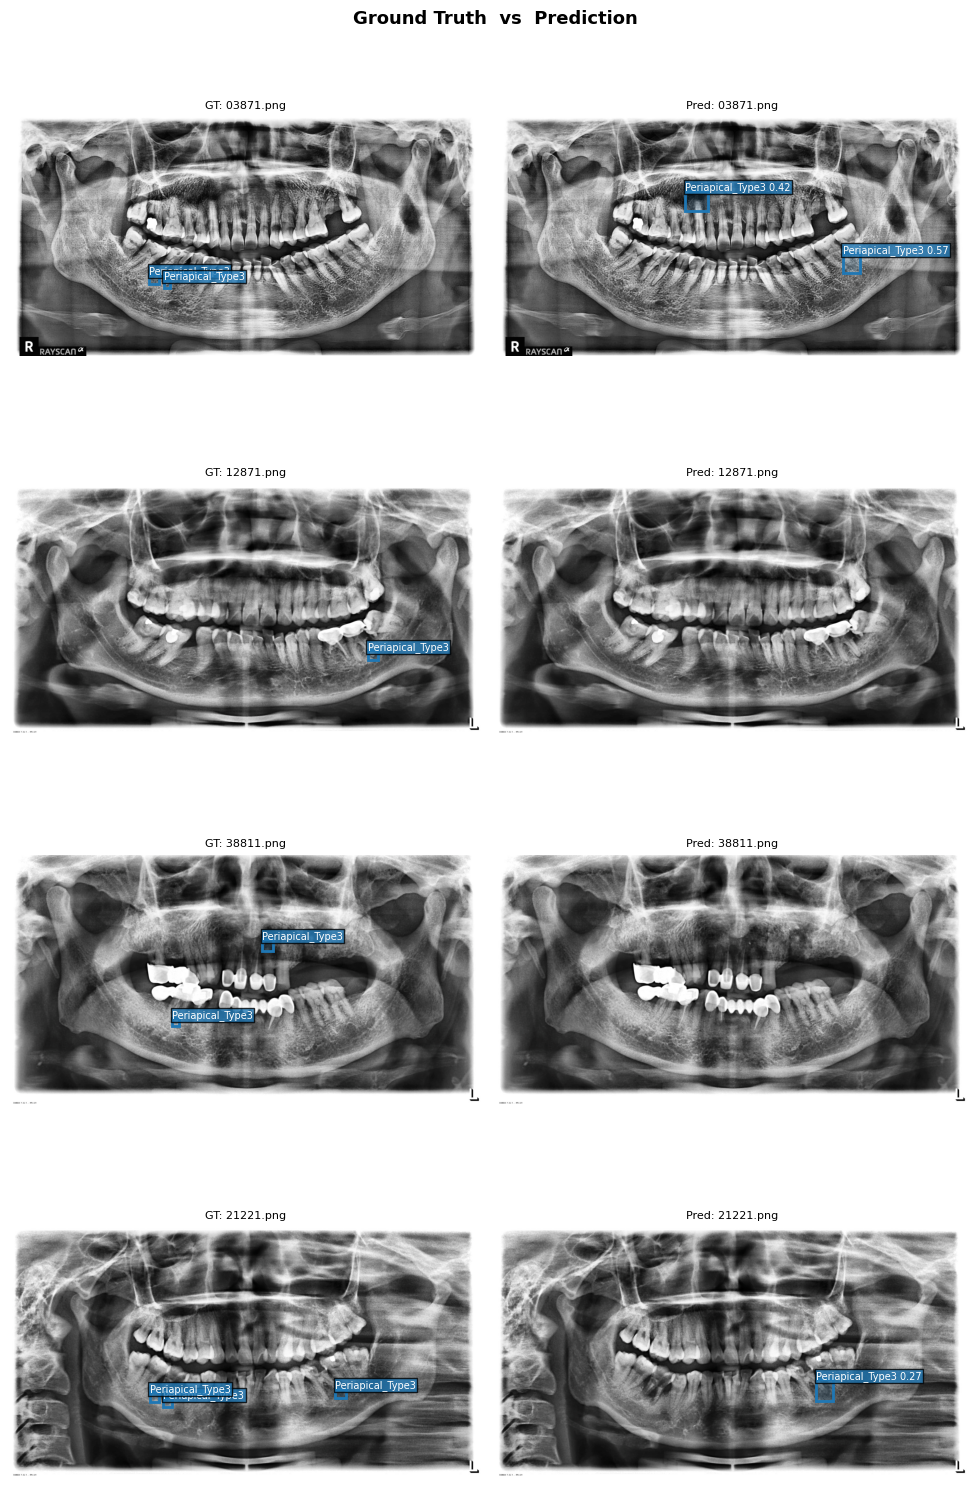

In [21]:
# ── Ground-truth vs Prediction side-by-side for 4 images ─────────────────────
def plot_gt_vs_pred(model, img_paths: list,
                    lbl_dir: Path, class_names: list,
                    conf: float = 0.25, n: int = 4):
    samples = random.sample(img_paths, min(n, len(img_paths)))
    cmap    = plt.cm.get_cmap('tab10', len(class_names))

    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    for row, img_path in enumerate(samples):
        img  = np.array(Image.open(img_path).convert('RGB'))
        h, w = img.shape[:2]

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img)
        ax_gt.set_title(f'GT: {img_path.name}', fontsize=8)
        ax_gt.axis('off')
        lbl_p = lbl_dir / (img_path.stem + '.txt')
        if lbl_p.exists():
            for line in lbl_p.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_idx = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                color = cmap(cls_idx)
                rect  = mpatches.Rectangle((x1, y1), bw*w, bh*h,
                                            linewidth=2, edgecolor=color,
                                            facecolor=(*color[:3], 0.15))
                ax_gt.add_patch(rect)
                ax_gt.text(x1, y1 - 4, class_names[cls_idx],
                           color='white', fontsize=7,
                           bbox=dict(facecolor=color, alpha=0.8, pad=1))

        # Prediction
        ax_pr = axes[row, 1]
        ax_pr.imshow(img)
        ax_pr.set_title(f'Pred: {img_path.name}', fontsize=8)
        ax_pr.axis('off')
        preds = model.predict(source=str(img_path), conf=conf,
                              verbose=False, imgsz=1280)
        r     = preds[0]
        if r.boxes is not None and len(r.boxes):
            for box, cls_id, score in zip(
                    r.boxes.xyxy.cpu().numpy(),
                    r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy()):
                color = cmap(cls_id)
                x1, y1, x2, y2 = box
                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                           linewidth=2, edgecolor=color,
                                           facecolor=(*color[:3], 0.15))
                ax_pr.add_patch(rect)
                ax_pr.text(x1, y1 - 4,
                           f'{class_names[cls_id]} {score:.2f}',
                           color='white', fontsize=7,
                           bbox=dict(facecolor=color, alpha=0.8, pad=1))

    plt.suptitle('Ground Truth  vs  Prediction', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_gt_vs_pred(best_model, test_imgs,
                lbl_dir     = TILED_DIR / 'labels' / 'test',
                class_names = CLASS_DISPLAY,
                conf        = 0.25,
                n           = 4)

## 7. Error Analysis

We identify 3 error types:
1. **False Positives (FP):** predicted boxes with no matching GT
2. **False Negatives (FN):** GT boxes that were missed
3. **Low-confidence TPs:** correct detections with confidence < 0.5

In [22]:
def iou_boxes(b1, b2):
    """IoU between two xyxy boxes."""
    x1 = max(b1[0], b2[0]);  y1 = max(b1[1], b2[1])
    x2 = min(b1[2], b2[2]);  y2 = min(b1[3], b2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def collect_error_cases(model, img_paths, lbl_dir, class_names,
                         conf=0.25, iou_thr=0.5, max_cases=20):
    fp_cases, fn_cases, lc_cases = [], [], []

    for img_path in img_paths:
        img  = Image.open(img_path).convert('RGB')
        w, h = img.size

        lbl_p    = lbl_dir / (img_path.stem + '.txt')
        gt_boxes = []
        if lbl_p.exists():
            for line in lbl_p.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_idx = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                x2 = (xc + bw/2) * w
                y2 = (yc + bh/2) * h
                gt_boxes.append({'cls': cls_idx, 'box': [x1, y1, x2, y2]})

        result     = model.predict(source=str(img_path), conf=conf,
                                   verbose=False, imgsz=1280)[0]
        pred_boxes = []
        if result.boxes is not None:
            for box, cls_id, score in zip(
                    result.boxes.xyxy.cpu().numpy(),
                    result.boxes.cls.cpu().numpy().astype(int),
                    result.boxes.conf.cpu().numpy()):
                pred_boxes.append({'cls': cls_id, 'box': box.tolist(), 'conf': score})

        matched_gt   = set()
        matched_pred = set()

        for pi, p in enumerate(pred_boxes):
            for gi, g in enumerate(gt_boxes):
                if gi in matched_gt:
                    continue
                if iou_boxes(p['box'], g['box']) >= iou_thr:
                    matched_gt.add(gi)
                    matched_pred.add(pi)
                    if p['conf'] < 0.5 and len(lc_cases) < max_cases:
                        lc_cases.append((img_path, pred_boxes, gt_boxes))
                    break

        if any(pi not in matched_pred for pi in range(len(pred_boxes))):
            if len(fp_cases) < max_cases:
                fp_cases.append((img_path, pred_boxes, gt_boxes))

        if any(gi not in matched_gt for gi in range(len(gt_boxes))):
            if len(fn_cases) < max_cases:
                fn_cases.append((img_path, pred_boxes, gt_boxes))

    return fp_cases, fn_cases, lc_cases


print('Collecting error cases (this may take a few minutes)…')
fp_cases, fn_cases, lc_cases = collect_error_cases(
    best_model, test_imgs[:200],
    lbl_dir     = TILED_DIR / 'labels' / 'test',
    class_names = CLASS_DISPLAY,
    conf        = 0.25,
    iou_thr     = 0.5,
    max_cases   = 20,
)
print(f'  False Positives  : {len(fp_cases)}')
print(f'  False Negatives  : {len(fn_cases)}')
print(f'  Low-conf TPs     : {len(lc_cases)}')

  False Positives  : 20
  False Negatives  : 20
  Low-conf TPs     : 20


In [23]:
def show_error_cases(cases, class_names, title='Error Cases', n=6):
    if not cases:
        print(f'No cases found for: {title}')
        return
    samples = cases[:n]
    cmap    = plt.cm.get_cmap('tab10', len(class_names))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, (img_path, preds, gts) in zip(axes, samples):
        img = np.array(Image.open(img_path).convert('RGB'))
        ax.imshow(img)
        ax.set_title(Path(img_path).name, fontsize=7)
        ax.axis('off')
        for g in gts:
            x1, y1, x2, y2 = g['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, class_names[g['cls']], color='lime', fontsize=7)
        for p in preds:
            x1, y1, x2, y2 = p['box']
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red',
                                       facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x2, y1 - 4, f"{class_names[p['cls']]} {p['conf']:.2f}",
                    color='red', fontsize=7)

    legend = [
        mpatches.Patch(edgecolor='lime', facecolor='none', label='Ground Truth'),
        mpatches.Patch(edgecolor='red',  facecolor='none', label='Prediction', linestyle='--'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_error_cases(fp_cases, CLASS_DISPLAY, title=' False Positives (spurious detections)')
show_error_cases(fn_cases, CLASS_DISPLAY, title=' False Negatives (missed detections)')
show_error_cases(lc_cases, CLASS_DISPLAY, title='  Low-confidence True Positives (conf < 0.5)')

Output hidden; open in https://colab.research.google.com to view.

## 8. Model Export

In [24]:
DRIVE_EXPORT_ROOT = WORK_DIR / 'yolo-periapical' / 'exports'

# ── Export to ONNX ───────────────────────────────────────────────────────────
onnx_path = best_model.export(format='onnx', imgsz=1280, dynamic=False, simplify=True)
print(f' ONNX exported      : {onnx_path}')

# ── Export to TorchScript ────────────────────────────────────────────────────
ts_path = best_model.export(format='torchscript', imgsz=1280)
print(f'TorchScript exported: {ts_path}')

# ── Copy exports to Google Drive ─────────────────────────────────────────────
DRIVE_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

for p in [BEST_PT, Path(str(onnx_path)), Path(str(ts_path))]:
    if p.exists():
        shutil.copy2(p, DRIVE_EXPORT_ROOT / p.name)
        print(f'   Copied {p.name} → {DRIVE_EXPORT_ROOT}')

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/Colab Notebooks/runs/periapical_det_v55/weights/best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 7, 33600) (49.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 193ms
Prepared 4 packages in 3.40s
Installed 4 packages in 287ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 4.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export 

## 9. Inference Utility Function

/tmp/ipykernel_2912/582475027.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(CLASS_DISPLAY))



  Image  : /content/drive/MyDrive/Colab Notebooks/filtered_tiles/images/test/12891.png
  Preprocessing applied: False
  Objects detected: 0
  No lesions detected at this confidence threshold.


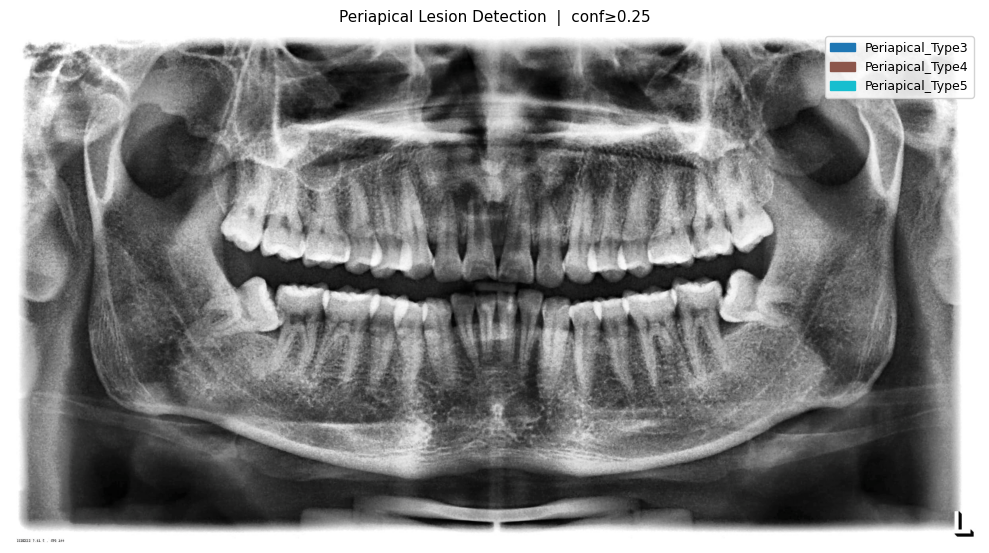

In [25]:
def predict_image(image_path: str,
                  conf: float = 0.25,
                  model_path: str = None,
                  apply_preprocessing: bool = True) -> None:
    """
    Run periapical lesion detection on a single dental X-ray and display results.

    Parameters
    ----------
    image_path          : str or Path – path to the input image
    conf                : float       – confidence threshold (default 0.25)
    model_path          : str or None – path to best.pt; auto-detected if None
    apply_preprocessing : bool        – run CLAHE + normalisation before inference
                                        (should match training; default True)
    """
    if model_path is None:
        model_path = str(BEST_PT)
    inf_model = YOLO(model_path)

    # ── Optionally preprocess to match training domain ──────────────────────
    image_path = Path(image_path)
    if apply_preprocessing:
        img_rgb   = preprocess_image(image_path)
        # Save to a temp file so YOLO can read it
        tmp_path  = Path('/tmp/_pred_input.png')
        cv2.imwrite(str(tmp_path), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        src = tmp_path
    else:
        src = image_path

    results = inf_model.predict(
        source  = str(src),
        conf    = conf,
        imgsz   = 1280,
        verbose = False,
    )
    r   = results[0]
    img = np.array(Image.open(src).convert('RGB'))
    cmap = plt.cm.get_cmap('tab10', len(CLASS_DISPLAY))

    print(f"\n{'='*55}")
    print(f'  Image  : {image_path}')
    print(f'  Preprocessing applied: {apply_preprocessing}')
    print(f'  Objects detected: {len(r.boxes) if r.boxes else 0}')
    print(f"{'='*55}")

    if r.boxes is not None and len(r.boxes):
        for i, (cls_id, score, box) in enumerate(
                zip(r.boxes.cls.cpu().numpy().astype(int),
                    r.boxes.conf.cpu().numpy(),
                    r.boxes.xyxy.cpu().numpy())):
            print(f'  [{i+1}] {CLASS_DISPLAY[cls_id]:<25}  conf={score:.3f}  '
                  f'box=[{box[0]:.0f},{box[1]:.0f},{box[2]:.0f},{box[3]:.0f}]')
    else:
        print('  No lesions detected at this confidence threshold.')

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Periapical Lesion Detection  |  conf≥{conf}', fontsize=11)

    if r.boxes is not None and len(r.boxes):
        for box, cls_id, score in zip(
                r.boxes.xyxy.cpu().numpy(),
                r.boxes.cls.cpu().numpy().astype(int),
                r.boxes.conf.cpu().numpy()):
            color = cmap(cls_id)
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2.5, edgecolor=color,
                                       facecolor=(*color[:3], 0.20))
            ax.add_patch(rect)
            label = f'{CLASS_DISPLAY[cls_id]}\n{score:.2f}'
            ax.text(x1, y1 - 6, label, color='white', fontsize=9,
                    fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.85, pad=2))

    legend = [mpatches.Patch(color=cmap(i), label=CLASS_DISPLAY[i])
              for i in range(len(CLASS_DISPLAY))]
    ax.legend(handles=legend, loc='upper right', fontsize=9, framealpha=0.85)
    plt.tight_layout()
    plt.show()


# ── Demo: run on a random test image ────────────────────────────────────────
if test_imgs:
    demo_img = random.choice(test_imgs)
    predict_image(str(demo_img), conf=0.25, apply_preprocessing=False)
    # apply_preprocessing=False because test_imgs already went through
    # the pipeline in Section 3; set True for raw unseen images.